# Дашборд конверсий

Самостоятельный notebook для полного запуска и автотестов Хекслета.
Настройки `API_URL`, `DATE_BEGIN`, `DATE_END` читаются из окружения, затем из
`./.env` для отсутствующих значений. Переменные окружения имеют приоритет.
Входной файл рекламы — `./ads.csv`. Результаты — `./conversion.json`,
`./ads.json` и девять PNG в `./charts`. Все пути относительно рабочей директории.
Другие notebooks и предварительно рассчитанные JSON не нужны.

In [1]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dotenv import load_dotenv

load_dotenv("./.env", override=False)
API_URL = os.getenv("API_URL")
DATE_BEGIN = os.getenv("DATE_BEGIN")
DATE_END = os.getenv("DATE_END")
if not all([API_URL, DATE_BEGIN, DATE_END]):
    raise ValueError("Задайте API_URL, DATE_BEGIN и DATE_END в окружении или .env")
for value in [DATE_BEGIN, DATE_END]:
    parsed = pd.to_datetime(value, format="%Y-%m-%d", errors="raise")
    if parsed.strftime("%Y-%m-%d") != value:
        raise ValueError("Даты должны иметь формат YYYY-MM-DD")
if DATE_BEGIN > DATE_END:
    raise ValueError("DATE_BEGIN не должна быть позже DATE_END")
API_BASE_URL = API_URL.rstrip("/")
API_PERIOD = {"begin": DATE_BEGIN, "end": DATE_END}
os.makedirs("./charts", exist_ok=True)

## Получение данных API

In [2]:
def fetch_api_data(endpoint, expected_columns):
    response = requests.get(
        f"{API_BASE_URL}/{endpoint}",
        params=API_PERIOD,
        timeout=120,
    )
    response.raise_for_status()
    records = response.json()
    if not isinstance(records, list):
        raise ValueError(f"{endpoint}: ожидался JSON-массив записей")
    if not all(isinstance(record, dict) for record in records):
        raise ValueError(f"{endpoint}: каждая запись должна быть JSON-объектом")
    if not all(set(expected_columns).issubset(record) for record in records):
        raise ValueError(f"{endpoint}: в записях отсутствуют обязательные поля")

    frame = pd.DataFrame(records, columns=expected_columns).astype("string")
    print(f"{endpoint}: HTTP {response.status_code}, строк: {len(frame):,}")
    return frame


api_visits = fetch_api_data(
    "visits", ["visit_id", "platform", "user_agent", "datetime"]
)
api_registrations = fetch_api_data(
    "registrations",
    ["user_id", "email", "platform", "registration_type", "datetime"],
)

visits: HTTP 200, строк: 263,459


registrations: HTTP 200, строк: 21,836


## Конверсия

Ботов исключаем по `bot` в User-Agent без учёта регистра. Используем платформы
`web`, `android`, `ios`. Для каждого посетителя выбираем последний визит за весь
период; при равном времени — последнюю запись в ответе. Конверсия в процентах.
Группы без визитов сохраняем с неопределённой конверсией (`null` в JSON).

In [3]:
def calculate_conversion(visits_data, registrations_data):
    platforms = ["android", "ios", "web"]
    is_bot = visits_data["user_agent"].str.contains("bot", case=False, na=False)
    human_visits = visits_data.loc[
        ~is_bot & visits_data["platform"].isin(platforms)
    ].copy()
    human_visits["datetime"] = pd.to_datetime(
        human_visits["datetime"], format="ISO8601", errors="raise"
    )
    last_visits = (
        human_visits.sort_values("datetime", kind="stable")
        .drop_duplicates("visit_id", keep="last").copy()
    )
    last_visits["date_group"] = last_visits["datetime"].dt.normalize()
    visits_by_day = (
        last_visits.groupby(["date_group", "platform"])
        .size().rename("visits").reset_index()
    )

    registrations = registrations_data.loc[
        registrations_data["platform"].isin(platforms)
    ].copy()
    registrations["date_group"] = pd.to_datetime(
        registrations["datetime"], format="ISO8601", errors="raise"
    ).dt.normalize()
    registrations_by_day = (
        registrations.groupby(["date_group", "platform"])
        .size().rename("registrations").reset_index()
    )

    result = visits_by_day.merge(
        registrations_by_day, on=["date_group", "platform"],
        how="outer", validate="one_to_one",
    )
    result[["visits", "registrations"]] = (
        result[["visits", "registrations"]].fillna(0).astype("int64")
    )
    denominator = result["visits"].where(result["visits"].ne(0))
    result["conversion"] = result["registrations"].div(denominator).mul(100)
    return (
        result[["date_group", "platform", "visits", "registrations", "conversion"]]
        .sort_values(["date_group", "platform"]).reset_index(drop=True)
    )


conversion = calculate_conversion(api_visits, api_registrations)
conversion.head(9)

,date_group,platform,visits,registrations,conversion
0,2023-03-01,android,75,61,81.333333
1,2023-03-01,ios,22,18,81.818182
2,2023-03-01,web,279,8,2.867384
3,2023-03-02,android,67,59,88.059701
4,2023-03-02,ios,31,24,77.419355
5,2023-03-02,web,515,23,4.466019
6,2023-03-03,android,26,22,84.615385
7,2023-03-03,ios,40,34,85.000000
8,2023-03-03,web,617,51,8.265802


In [4]:
conversion.to_json("./conversion.json", orient="columns", date_format="epoch", date_unit="ms")

/var/folders/m7/35gwjyss2wb45fxn4yvdxbm80000gn/T/ipykernel_17271/379376667.py:1: Pandas4Warning: 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  conversion.to_json("./conversion.json", orient="columns", date_format="epoch", date_unit="ms")


## Реклама из локального CSV

Одна строка на день. Суммируем затраты всех кампаний дня, названия объединяем
без повторов. Это не распределение визитов по кампаниям. Для дней без рекламы
используем 0 и `none`. Рекламу вне дат метрик не включаем.

In [5]:
ads = pd.read_csv("./ads.csv")
ads["date_group"] = pd.to_datetime(ads["date"], format="ISO8601", errors="raise").dt.normalize()
ads["cost"] = pd.to_numeric(ads["cost"], errors="raise")
if ads[["date_group", "cost", "utm_campaign"]].isna().any().any():
    raise ValueError("В рекламе отсутствуют даты, затраты или названия кампаний")

In [6]:
def combine_advertising(conversion_data, advertising_data):
    daily_conversion = conversion_data.groupby("date_group", as_index=False).agg(
        visits=("visits", "sum"), registrations=("registrations", "sum"),
    )
    daily_ads = advertising_data.groupby("date_group", as_index=False).agg(
        cost=("cost", "sum"),
        utm_campaign=("utm_campaign", lambda names: ", ".join(sorted(names.unique()))),
    )
    result = daily_conversion.merge(
        daily_ads, on="date_group", how="left", validate="one_to_one",
    )
    result["cost"] = result["cost"].fillna(0)
    result["utm_campaign"] = result["utm_campaign"].fillna("none")
    return (
        result[["date_group", "visits", "registrations", "cost", "utm_campaign"]]
        .sort_values("date_group").reset_index(drop=True)
    )


ads_result = combine_advertising(conversion, ads)
ads_result.head(10)

,date_group,visits,registrations,cost,utm_campaign
0,2023-03-01,376,87,238.0,virtual_reality_workshop
1,2023-03-02,613,106,164.0,virtual_reality_workshop
2,2023-03-03,683,107,240.0,virtual_reality_workshop
3,2023-03-04,647,159,167.0,virtual_reality_workshop
4,2023-03-05,707,115,268.0,virtual_reality_workshop
5,2023-03-06,1291,230,126.0,virtual_reality_workshop
6,2023-03-07,1382,124,191.0,virtual_reality_workshop
7,2023-03-08,1382,151,165.0,virtual_reality_workshop
8,2023-03-09,1064,209,121.0,virtual_reality_workshop
9,2023-03-10,812,112,122.0,virtual_reality_workshop


In [7]:
ads_result.to_json("./ads.json", orient="columns", date_format="epoch", date_unit="ms")

/var/folders/m7/35gwjyss2wb45fxn4yvdxbm80000gn/T/ipykernel_17271/132006572.py:1: Pandas4Warning: 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  ads_result.to_json("./ads.json", orient="columns", date_format="epoch", date_unit="ms")


## Девять графиков

Дневные показатели без сглаживания. Средняя конверсия взвешена по визитам:
сумма регистраций / сумма визитов × 100%. Валюта затрат не указана в источнике.
Цвет кампании обозначает её наличие в этот день, а не причинный эффект рекламы.

In [8]:
conversion = conversion.sort_values("date_group")
ads = ads_result.sort_values("date_group")
assert not conversion.duplicated(["date_group", "platform"]).any()
assert ads["date_group"].is_unique
daily = conversion.groupby("date_group")[["visits", "registrations"]].sum().sort_index()
daily["conversion"] = daily["registrations"].div(daily["visits"].where(daily["visits"].ne(0))).mul(100)
pd.testing.assert_frame_equal(
    daily[["visits", "registrations"]],
    ads.set_index("date_group")[["visits", "registrations"]],
)
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 17, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})
platform_colors = {"web": "#2563eb", "android": "#15966a", "ios": "#a855c7"}
chart_files = []


def new_chart(title, ylabel):
    fig, ax = plt.subplots(figsize=(13, 5.5), layout="constrained")
    ax.set_title(title, loc="left", pad=16)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Дата, 2023 год")
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)
    ax.margins(x=0.01)
    return fig, ax


def save_chart(fig, filename):
    for ax in fig.axes:
        ax.set_ylim(bottom=0)
    fig.savefig(f"./charts/{filename}", dpi=160, facecolor="white")
    chart_files.append(filename)
    plt.show()
    plt.close(fig)

## Итоговые визиты

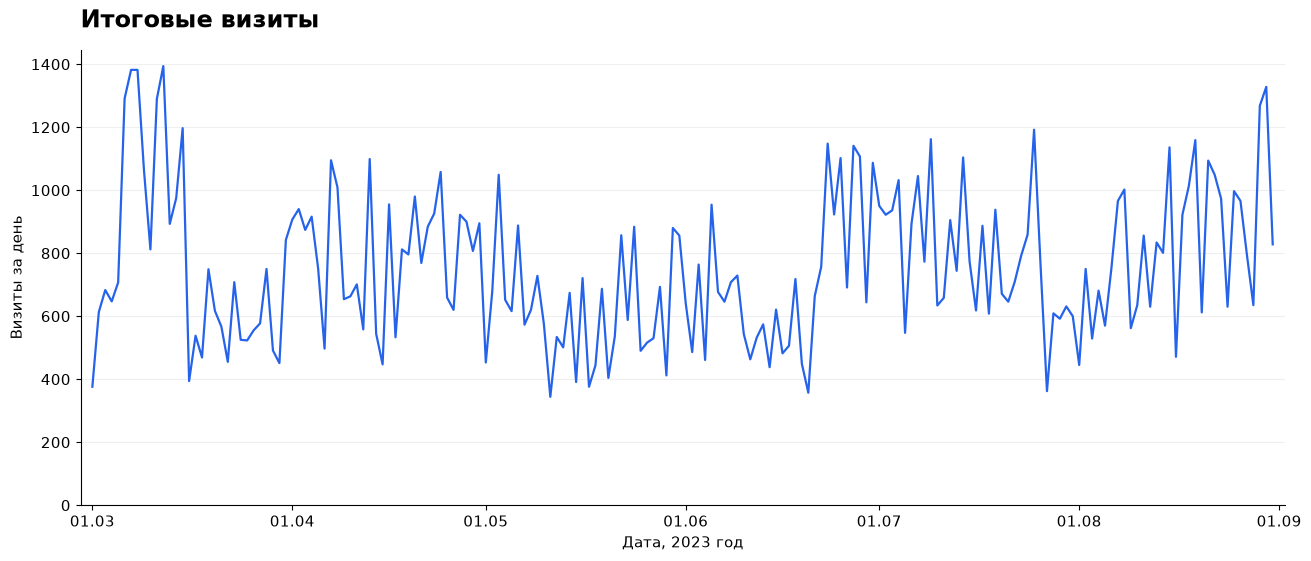

In [9]:
fig, ax = new_chart("Итоговые визиты", "Визиты за день")
ax.plot(daily.index, daily["visits"], color="#2563eb", linewidth=1.6)
save_chart(fig, "visits.png")

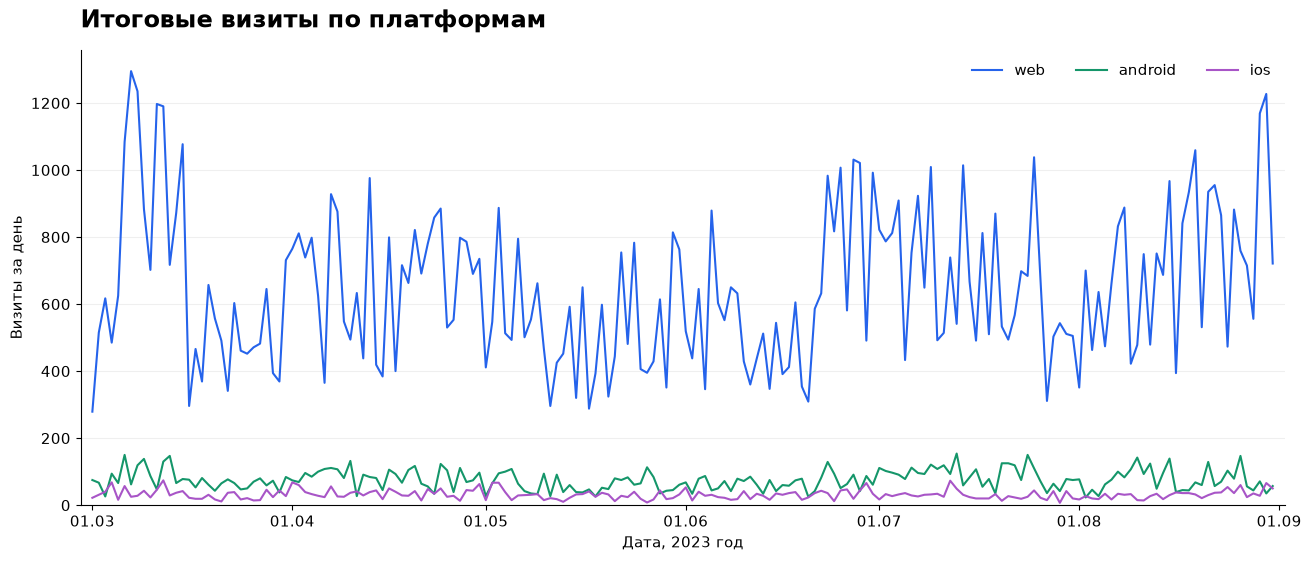

In [10]:
fig, ax = new_chart("Итоговые визиты по платформам", "Визиты за день")
for platform, color in platform_colors.items():
    series = conversion.loc[conversion["platform"].eq(platform)].set_index("date_group")["visits"]
    ax.plot(series.index, series, label=platform, color=color, linewidth=1.5)
ax.legend(frameon=False, ncol=3)
save_chart(fig, "visits_by_platform.png")

## Итоговые регистрации

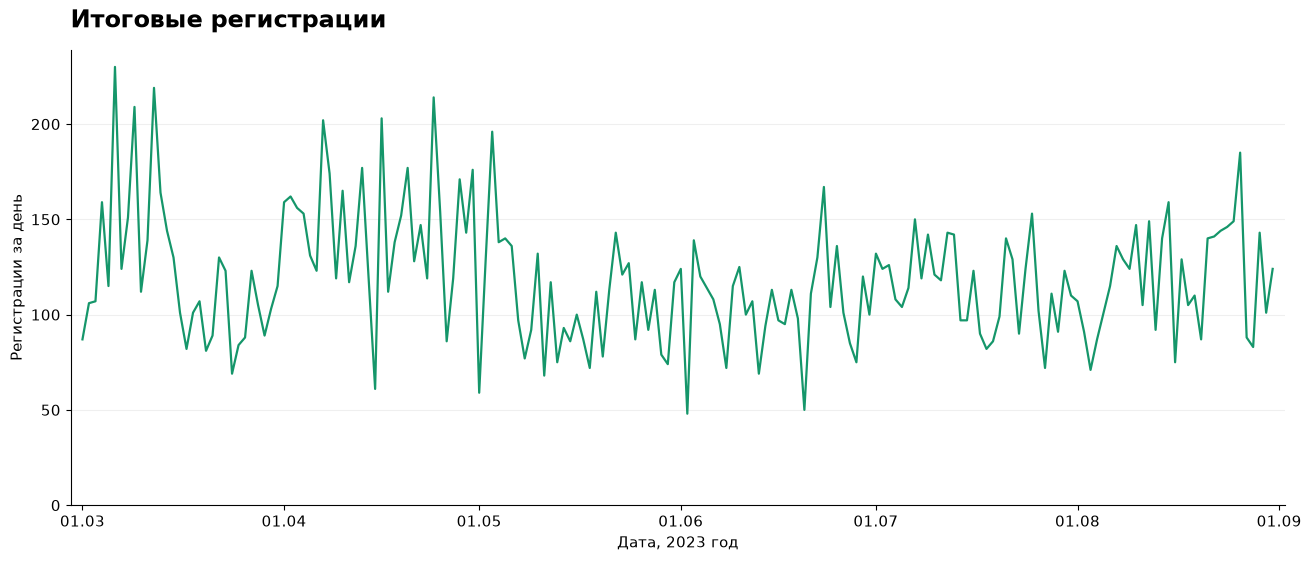

In [11]:
fig, ax = new_chart("Итоговые регистрации", "Регистрации за день")
ax.plot(daily.index, daily["registrations"], color="#15966a", linewidth=1.6)
save_chart(fig, "registrations.png")

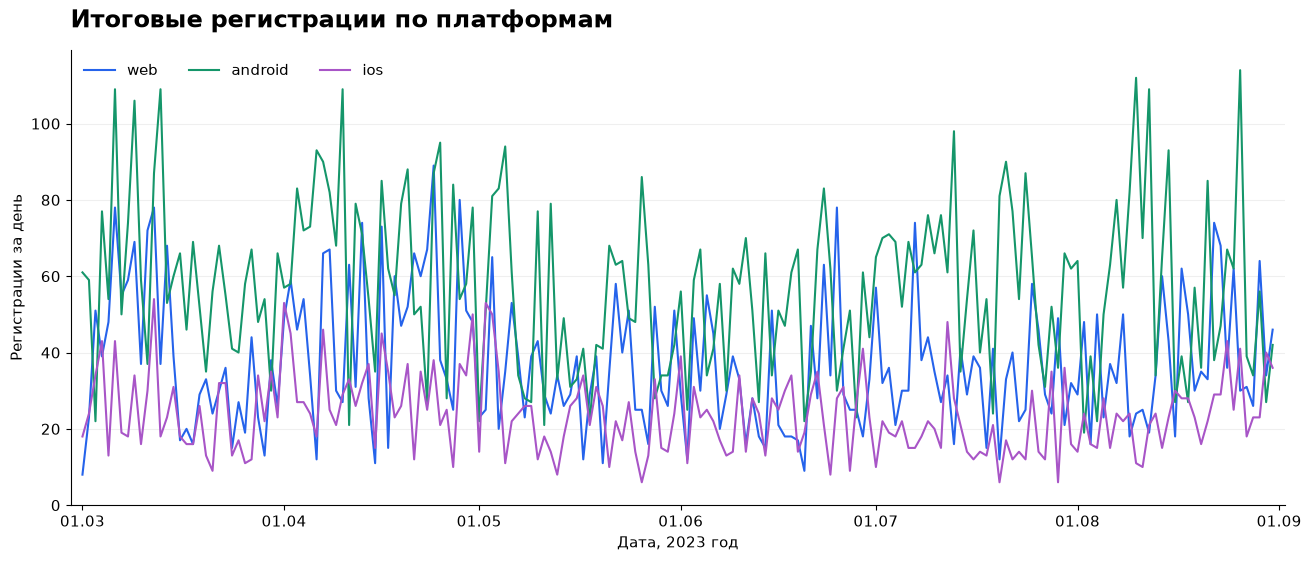

In [12]:
fig, ax = new_chart("Итоговые регистрации по платформам", "Регистрации за день")
for platform, color in platform_colors.items():
    series = conversion.loc[conversion["platform"].eq(platform)].set_index("date_group")["registrations"]
    ax.plot(series.index, series, label=platform, color=color, linewidth=1.5)
ax.legend(frameon=False, ncol=3)
save_chart(fig, "registrations_by_platform.png")

## Конверсия

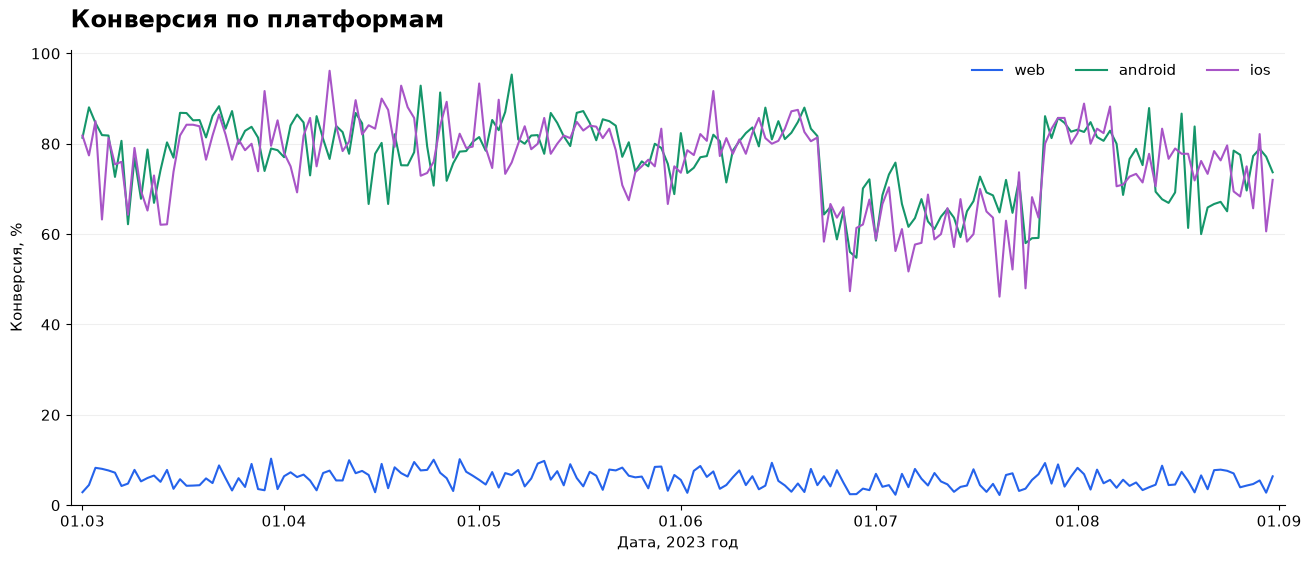

In [13]:
fig, ax = new_chart("Конверсия по платформам", "Конверсия, %")
for platform, color in platform_colors.items():
    series = conversion.loc[conversion["platform"].eq(platform)].set_index("date_group")["conversion"]
    ax.plot(series.index, series, label=platform, color=color, linewidth=1.5)
ax.legend(frameon=False, ncol=3)
save_chart(fig, "conversion_by_platform.png")

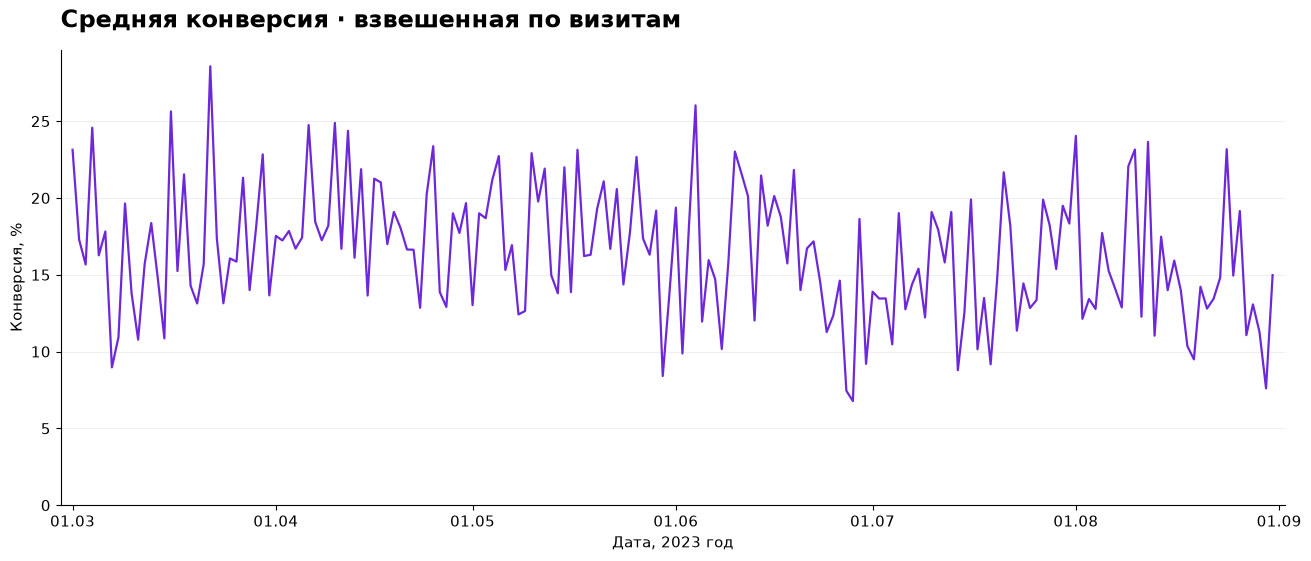

In [14]:
fig, ax = new_chart("Средняя конверсия · взвешенная по визитам", "Конверсия, %")
ax.plot(daily.index, daily["conversion"], color="#6d28d9", linewidth=1.6)
save_chart(fig, "average_conversion.png")

## Реклама

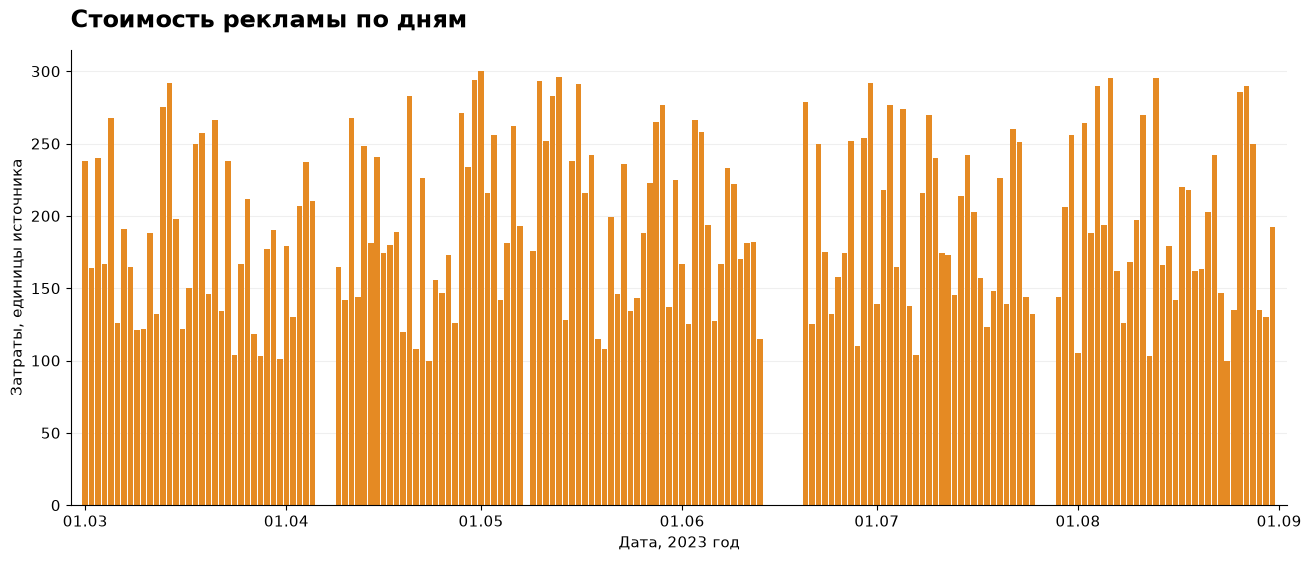

In [15]:
fig, ax = new_chart("Стоимость рекламы по дням", "Затраты, единицы источника")
ax.bar(ads["date_group"], ads["cost"], width=0.85, color="#e58a23")
save_chart(fig, "ads_cost.png")

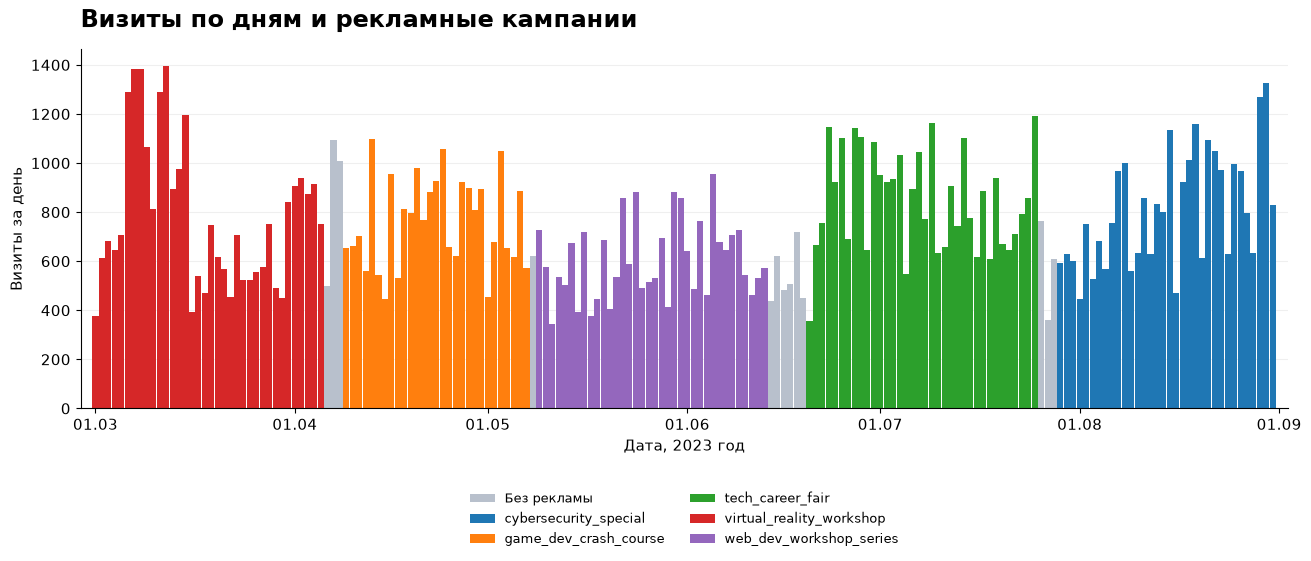

In [16]:
campaigns = sorted(name for name in ads["utm_campaign"].unique() if name != "none")
palette = plt.get_cmap("tab10")
campaign_colors = {name: palette(i % 10) for i, name in enumerate(campaigns)}
campaign_colors["none"] = "#b8c0cc"


def campaign_chart(metric, title, ylabel, filename):
    fig, ax = new_chart(title, ylabel)
    for campaign in ["none"] + campaigns:
        rows = ads.loc[ads["utm_campaign"].eq(campaign)]
        ax.bar(rows["date_group"], rows[metric], width=0.95,
               color=campaign_colors[campaign],
               label="Без рекламы" if campaign == "none" else campaign)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.20),
              ncol=2, frameon=False, fontsize=9)
    save_chart(fig, filename)


campaign_chart("visits", "Визиты по дням и рекламные кампании", "Визиты за день", "visits_with_ads.png")

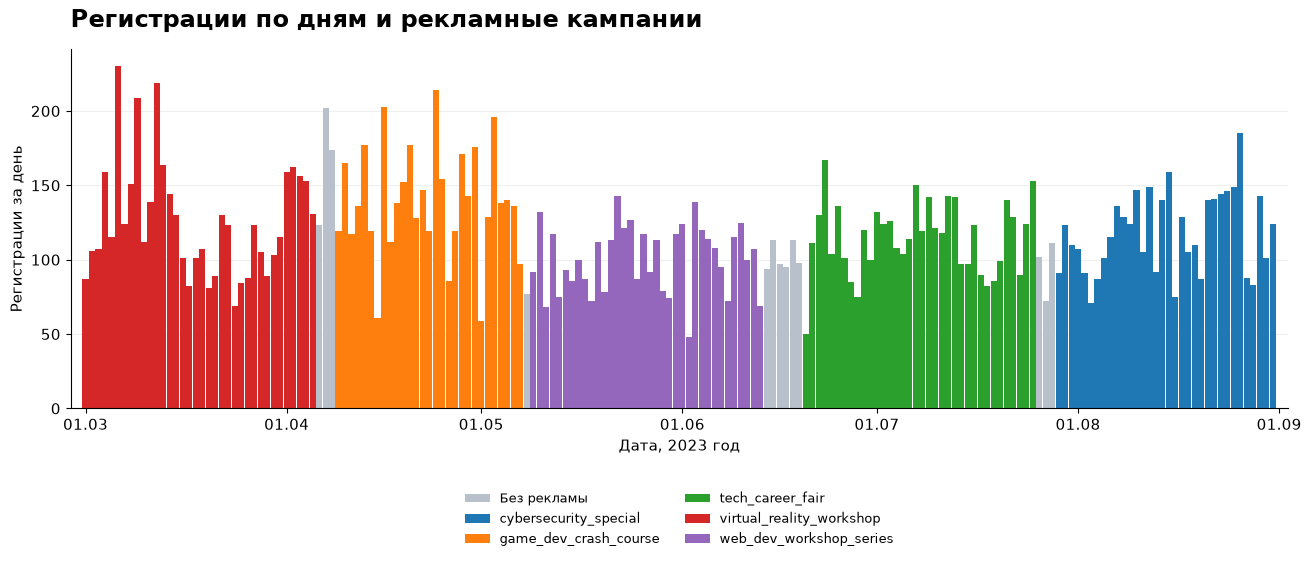

In [17]:
campaign_chart("registrations", "Регистрации по дням и рекламные кампании", "Регистрации за день", "registrations_with_ads.png")

In [18]:
assert len(chart_files) == 9 and len(set(chart_files)) == 9
chart_files

['visits.png',
 'visits_by_platform.png',
 'registrations.png',
 'registrations_by_platform.png',
 'conversion_by_platform.png',
 'average_conversion.png',
 'ads_cost.png',
 'visits_with_ads.png',
 'registrations_with_ads.png']